In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["PYTHONHASHSEED"] = "42"
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, roc_curve
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import random
import optuna
import copy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

In [2]:
train_df = pd.read_csv("data/Round3/90/changed_train_seqs_new.csv")
val_df = pd.read_csv("data/Round3/90/changed_val_seqs_validation.csv")
test_df = pd.read_csv("data/Round3/90/changed_test_seqs_new.csv")
val_test_df = pd.read_csv("data/Round3/90/changed_val_seqs_test.csv")

In [3]:
seq_cols = "CDR3 aligned"
amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
add_position = True

In [4]:
for df in (train_df, val_df, test_df, val_test_df):
    df["CDRs"] = df[seq_cols].astype(str)

train_lengths = train_df["CDRs"].str.len().iloc[0]
val_lengths = val_df["CDRs"].str.len().iloc[0]
test_lengths = test_df["CDRs"].str.len().iloc[0]
val_test_lengths = val_test_df["CDRs"].str.len().iloc[0]

assert train_lengths == val_lengths == test_lengths == val_test_lengths
assert (train_df["CDRs"].str.len() == train_lengths).all()
assert (val_df["CDRs"].str.len() == val_lengths).all()
assert (test_df["CDRs"].str.len() == test_lengths).all()
assert (val_test_df["CDRs"].str.len() == val_test_lengths).all()

In [ ]:
aa2idx = {aa: i for i, aa in enumerate(amino_acids)}
I = np.eye(len(amino_acids),dtype=np.float32)

In [ ]:
def one_hot_encode(seq, add_position=True):
    feats = []
    L = len(seq)
    for i, a in enumerate(seq):
        v = I[aa2idx.get(a, aa2idx["-"])]
        
        if add_position:
            v = np.concatenate((v, [i / L]))
        feats.append(v)

    return np.array(feats, dtype=np.float32)   


In [ ]:
def build_tensors(df):
    seqs = [torch.tensor(one_hot_encode(seq), dtype=torch.float32)
            for seq in df["CDRs"]]
    
    X = pad_sequence(seqs, batch_first=True) 
    y = torch.tensor(df["Label"].values, dtype=torch.long)
    return X, y

x_train_tensor, y_train_tensor = build_tensors(train_df)
x_val_tensor, y_val_tensor     = build_tensors(val_df)
x_test_tensor, y_test_tensor   = build_tensors(test_df)
x_val_test_tensor, y_val_test_tensor = build_tensors(val_test_df)

In [ ]:
class ProteinCNN(nn.Module):
    def __init__(
        self,
        input_dim=22,
        num_classes=2,
        num_blocks=3,
        base_ch=64,
        kernel_size=7,
        dropout=0.3,
        hidden_dim=128
    ):
        super().__init__()

        layers = []
        in_ch = input_dim
        padding = kernel_size // 2

        channel_sizes = [base_ch * (2 ** i) for i in range(num_blocks)]

        for out_ch in channel_sizes:
            layers.append(nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding))
            layers.append(nn.BatchNorm1d(out_ch))
            layers.append(nn.ReLU())
            in_ch = out_ch

        self.conv = nn.Sequential(*layers)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(channel_sizes[-1], hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [9]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            all_labels.extend(y_batch.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)
    val_ap = average_precision_score(all_labels, all_probs)

    return avg_loss, val_f1, val_ap

In [11]:
def train_one_trial(params, x_train_tensor, y_train_tensor, x_val_tensor, y_val_tensor, device):
    set_seed(seed)
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        generator=g,
        num_workers=0
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=0
    )

    class_counts = torch.bincount(y_train_tensor)
    class_weights = class_counts.sum().float() / (len(class_counts) * class_counts.float())
    class_weights = class_weights.to(device)

    model = ProteinCNN(
        input_dim=x_train_tensor.shape[2],
        num_blocks=params["num_blocks"],
        base_ch=params["base_ch"],
        kernel_size=params["kernel_size"],
        dropout=params["dropout"],
        hidden_dim=params["hidden_dim"]
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    if params["optimizer"] == "adamw":
        optimizer = torch.optim.AdamW(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    elif params["optimizer"] == "sgd":
        optimizer = torch.optim.SGD(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"], momentum=0.9
    )

    best_val_ap = -1
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(params["epochs"]):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        val_loss, val_f1, val_ap = evaluate_model(model, val_loader, criterion, device)

        if val_ap > best_val_ap:
            best_val_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= params["patience"]:
            break

    model.load_state_dict(best_state)
    final_val_loss, final_val_f1, final_val_ap = evaluate_model(model, val_loader, criterion, device)

    return model, final_val_ap, final_val_f1, final_val_loss, best_epoch

In [12]:
def objective(trial):
    base_ch = trial.suggest_categorical("base_ch", [32, 64, 96])
    num_blocks = trial.suggest_int("num_blocks", 2, 4)

    params = {
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "num_blocks": num_blocks,
        "base_ch": base_ch,
        "kernel_size": trial.suggest_categorical("kernel_size", [5, 7, 9, 11, 13, 15]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "hidden_dim": trial.suggest_categorical("hidden_dim", [64, 128, 256]),
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adamw", "sgd"]),
        "epochs": 30,
        "patience": 4,
    }

    model, val_ap, val_f1, val_loss, best_epoch = train_one_trial(
        params,
        x_train_tensor, y_train_tensor,
        x_val_tensor, y_val_tensor,
        device
    )

    trial.set_user_attr("val_f1", val_f1)
    trial.set_user_attr("val_loss", val_loss)
    trial.set_user_attr("best_epoch", best_epoch)

    return val_ap

In [13]:
sampler = optuna.samplers.TPESampler(seed=seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=20)

[I 2026-04-22 11:15:19,758] A new study created in memory with name: no-name-af8701da-737e-4a8b-9b50-c02d9c355e24


[I 2026-04-22 11:17:09,672] Trial 0 finished with value: 0.6044244439458311 and parameters: {'base_ch': 64, 'num_blocks': 3, 'batch_size': 32, 'kernel_size': 13, 'dropout': 0.18493564427131048, 'hidden_dim': 256, 'lr': 0.0005958389350068958, 'weight_decay': 1.9762189340280066e-05, 'optimizer': 'sgd'}. Best is trial 0 with value: 0.6044244439458311.


[I 2026-04-22 11:18:56,854] Trial 1 finished with value: 0.6072671506410029 and parameters: {'base_ch': 96, 'num_blocks': 3, 'batch_size': 32, 'kernel_size': 15, 'dropout': 0.4862528132298237, 'hidden_dim': 64, 'lr': 0.0010249322216924156, 'weight_decay': 2.091498132903561e-05, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.6072671506410029.


[I 2026-04-22 11:19:44,750] Trial 2 finished with value: 0.5837801131165493 and parameters: {'base_ch': 64, 'num_blocks': 3, 'batch_size': 128, 'kernel_size': 7, 'dropout': 0.4687496940092467, 'hidden_dim': 128, 'lr': 0.0003023795012558478, 'weight_decay': 1.4656553886225336e-05, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.6072671506410029.


[I 2026-04-22 11:20:03,805] Trial 3 finished with value: 0.5963955161390314 and parameters: {'base_ch': 96, 'num_blocks': 2, 'batch_size': 128, 'kernel_size': 11, 'dropout': 0.4085081386743783, 'hidden_dim': 128, 'lr': 0.0018832519048593583, 'weight_decay': 7.411299781083242e-05, 'optimizer': 'adamw'}. Best is trial 1 with value: 0.6072671506410029.


...

[I 2026-04-22 11:33:48,448] Trial 15 finished with value: 0.5987273254556529 and parameters: {'base_ch': 96, 'num_blocks': 2, 'batch_size': 32, 'kernel_size': 13, 'dropout': 0.3124586477477203, 'hidden_dim': 256, 'lr': 0.0014171394583181343, 'weight_decay': 0.0008960492177339139, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.6072671506410029.


[I 2026-04-22 11:35:12,511] Trial 16 finished with value: 0.6056980042370391 and parameters: {'base_ch': 64, 'num_blocks': 3, 'batch_size': 64, 'kernel_size': 15, 'dropout': 0.38858799654617926, 'hidden_dim': 64, 'lr': 0.0005027878985798109, 'weight_decay': 2.0788806579524092e-05, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.6072671506410029.


[I 2026-04-22 11:36:37,273] Trial 17 finished with value: 0.6114403043205137 and parameters: {'base_ch': 96, 'num_blocks': 3, 'batch_size': 64, 'kernel_size': 15, 'dropout': 0.41188454649877987, 'hidden_dim': 64, 'lr': 0.0004363523152146674, 'weight_decay': 2.9695030054519013e-06, 'optimizer': 'sgd'}. Best is trial 17 with value: 0.6114403043205137.


[I 2026-04-22 11:37:40,366] Trial 18 finished with value: 0.5918784345617271 and parameters: {'base_ch': 96, 'num_blocks': 4, 'batch_size': 64, 'kernel_size': 15, 'dropout': 0.4276269504938004, 'hidden_dim': 64, 'lr': 0.00018336957036240134, 'weight_decay': 3.026761975080237e-06, 'optimizer': 'adamw'}. Best is trial 17 with value: 0.6114403043205137.


[I 2026-04-22 11:38:52,870] Trial 19 finished with value: 0.5989931586632482 and parameters: {'base_ch': 96, 'num_blocks': 2, 'batch_size': 64, 'kernel_size': 15, 'dropout': 0.4374639453386894, 'hidden_dim': 64, 'lr': 0.001247673853617672, 'weight_decay': 1.273146013516494e-06, 'optimizer': 'sgd'}. Best is trial 17 with value: 0.6114403043205137.


In [14]:
print("Best AP:", study.best_value)
print("Best params:", study.best_trial.params)
print("Best val F1:", study.best_trial.user_attrs["val_f1"])
print("Best val loss:", study.best_trial.user_attrs["val_loss"])

Best AP: 0.6114403043205137
Best params: {'base_ch': 96, 'num_blocks': 3, 'batch_size': 64, 'kernel_size': 15, 'dropout': 0.41188454649877987, 'hidden_dim': 64, 'lr': 0.0004363523152146674, 'weight_decay': 2.9695030054519013e-06, 'optimizer': 'sgd'}
Best val F1: 0.5298382598996096
Best val loss: 0.6784028850454192


In [ ]:
best_params = study.best_trial.params
best_epoch = study.best_trial.user_attrs["best_epoch"]

final_params = {
    "batch_size": best_params["batch_size"],
    "num_blocks": best_params["num_blocks"],
    "base_ch": best_params["base_ch"],
    "kernel_size": best_params["kernel_size"],
    "dropout": best_params["dropout"],
    "hidden_dim": best_params["hidden_dim"],
    "lr": best_params["lr"],
    "weight_decay": best_params["weight_decay"],
    "optimizer": best_params["optimizer"],
    "epochs": best_epoch,
}

X_trainval = torch.cat([x_train_tensor, x_val_tensor], dim=0)
y_trainval = torch.cat([y_train_tensor, y_val_tensor], dim=0)

set_seed(seed)
g_final = torch.Generator()
g_final.manual_seed(seed)

trainval_dataset = TensorDataset(X_trainval, y_trainval)
trainval_loader = DataLoader(
    trainval_dataset,
    batch_size=final_params["batch_size"],
    shuffle=True,
    generator=g_final,
    num_workers=0
)

class_counts = torch.bincount(y_trainval)
class_weights = class_counts.sum().float() / (len(class_counts) * class_counts.float())
class_weights = class_weights.to(device)

final_model = ProteinCNN(
    input_dim=X_trainval.shape[2],
    num_blocks=final_params["num_blocks"],
    base_ch=final_params["base_ch"],
    kernel_size=final_params["kernel_size"],
    dropout=final_params["dropout"],
    hidden_dim=final_params["hidden_dim"]
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

if final_params["optimizer"] == "adamw":
    optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=final_params["lr"],
        weight_decay=final_params["weight_decay"]
    )
elif final_params["optimizer"] == "sgd":
    optimizer = torch.optim.SGD(
        final_model.parameters(),
        lr=final_params["lr"],
        weight_decay=final_params["weight_decay"],
        momentum=0.9
    )

for epoch in range(final_params["epochs"]):
    final_model.train()
    running_loss = 0.0

    for X_batch, y_batch in trainval_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = final_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(trainval_loader.dataset)
    print(f"Epoch {epoch+1}/{final_params['epochs']} - train+val loss: {epoch_loss:.4f}")

torch.save(final_model.state_dict(), "best_cdr3_cnn_optuna_final_trainval_90.pth")
print("Saved final retrained model.")

Epoch 1/28 - train+val loss: 0.7004


Epoch 2/28 - train+val loss: 0.6908


Epoch 3/28 - train+val loss: 0.6886


Epoch 4/28 - train+val loss: 0.6866


Epoch 5/28 - train+val loss: 0.6850


...

Epoch 24/28 - train+val loss: 0.6566


Epoch 25/28 - train+val loss: 0.6549


Epoch 26/28 - train+val loss: 0.6534


Epoch 27/28 - train+val loss: 0.6505


Epoch 28/28 - train+val loss: 0.6493
Saved final retrained model.


In [ ]:
def evaluate_model_on_split(model, X_tensor, y_tensor, df, split_name, batch_size=32):
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in tqdm(dataloader, desc=f"Evaluating {split_name}"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = np.argmax(logits.cpu().numpy(), axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    roc_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else np.nan
    c_report = classification_report(all_labels, all_preds)
    p, r, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(r, p)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n--- {split_name.upper()} results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:        {pr_auc:.4f}")
    print("Confusion matrix:")
    print(cm)
    print(c_report)

    results_df = df.copy()
    results_df["y_true"] = all_labels
    results_df["y_score"] = all_probs
    results_df["pred_label"] = all_preds

    metrics = {
        "split": split_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "classification_report": c_report
    }

    return results_df, metrics, all_labels, all_preds, all_probs


In [17]:
final_model = ProteinCNN(
    input_dim=X_trainval.shape[2],
    num_blocks=final_params["num_blocks"],
    base_ch=final_params["base_ch"],
    kernel_size=final_params["kernel_size"],
    dropout=final_params["dropout"],
    hidden_dim=final_params["hidden_dim"]
).to(device)

final_model.load_state_dict(torch.load("best_cdr3_cnn_optuna_final_trainval_90.pth", map_location=device))
final_model.eval()

ProteinCNN(
  (conv): Sequential(
    (0): Conv1d(22, 96, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(96, 192, kernel_size=(15,), stride=(1,), padding=(7,))
    (4): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(192, 384, kernel_size=(15,), stride=(1,), padding=(7,))
    (7): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.41188454649877987, inplace=False)
  (fc1): Linear(in_features=384, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [ ]:
test_results_df, test_metrics, y_test_true, y_test_pred, y_test_score = evaluate_model_on_split(
    model=final_model,
    X_tensor=x_test_tensor,
    y_tensor=y_test_tensor,
    df=test_df,
    split_name="test",
    batch_size = final_params["batch_size"]
)

val_test_results_df, val_test_metrics, y_val_test_true, y_val_test_pred, y_val_test_score = evaluate_model_on_split(
    model=final_model,
    X_tensor=x_val_test_tensor,
    y_tensor=y_val_test_tensor,
    df=val_test_df,
    split_name="val_test",
    batch_size = final_params["batch_size"]
)


Evaluating test:   0%|          | 0/785 [00:00<?, ?it/s]


Evaluating test:  15%|█▌        | 119/785 [00:00<00:00, 1185.48it/s]


Evaluating test:  30%|███       | 239/785 [00:00<00:00, 1191.70it/s]


Evaluating test:  46%|████▌     | 359/785 [00:00<00:00, 1193.52it/s]


Evaluating test:  61%|██████    | 479/785 [00:00<00:00, 1192.54it/s]

...


Evaluating test: 100%|██████████| 785/785 [00:00<00:00, 1184.72it/s]


--- TEST results ---
Accuracy:  0.5962
Precision: 0.6062
Recall:    0.6191
F1:        0.6126
ROC-AUC:   0.6376
PR-AUC:        0.6646
Confusion matrix:
[[13905 10409]
 [ 9859 16026]]
              precision    recall  f1-score   support

           0       0.59      0.57      0.58     24314
           1       0.61      0.62      0.61     25885

    accuracy                           0.60     50199
   macro avg       0.60      0.60      0.60     50199
weighted avg       0.60      0.60      0.60     50199




Evaluating val_test:   0%|          | 0/90 [00:00<?, ?it/s]


Evaluating val_test: 100%|██████████| 90/90 [00:00<00:00, 1143.54it/s]


--- VAL_TEST results ---
Accuracy:  0.5762
Precision: 0.5901
Recall:    0.5670
F1:        0.5783
ROC-AUC:   0.6058
PR-AUC:        0.6188
Confusion matrix:
[[1636 1156]
 [1271 1664]]
              precision    recall  f1-score   support

           0       0.56      0.59      0.57      2792
           1       0.59      0.57      0.58      2935

    accuracy                           0.58      5727
   macro avg       0.58      0.58      0.58      5727
weighted avg       0.58      0.58      0.58      5727



In [19]:
def evaluate_at_k(y_true, y_scores, clusters, k=100, split_name="Test"):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    clusters = np.asarray(clusters)

    assert len(y_true) == len(y_scores), "y_true and y_scores must have same length"
    assert len(y_true) == len(clusters), "y_true and clusters must have same length"

    k = min(k, len(y_true))
    top_idx = np.argsort(y_scores)[::-1][:k]
    y_topk = y_true[top_idx]

    precision_k = y_topk.sum() / k
    total_positives = y_true.sum()

    k_1000 = min(1000, len(y_true))
    top_idx_1000 = np.argsort(y_scores)[::-1][:k_1000]
    precision_1000 = y_true[top_idx_1000].sum() / k_1000

    positive_rate = total_positives / len(y_true)
    ef_k = (precision_k / positive_rate) if positive_rate > 0 else np.nan

    diversity_k = len(np.unique(clusters[top_idx]))
    total_unique_clusters = len(np.unique(clusters))
    normalized_diversity_k = (
        diversity_k / total_unique_clusters if total_unique_clusters > 0 else np.nan
    )

    print(f"\n================ {split_name.upper()} @ {k} ================\n")
    print(f"Precision@{k}:            {precision_k:.3f}")
    print(f"Precision@1000:           {precision_1000:.3f}")
    print(f"EF@{k}:                   {ef_k:.3f}" if not np.isnan(ef_k) else f"EF@{k}: NaN")
    print(f"Diversity@{k}:            {diversity_k}")
    print(
        f"Normalized Diversity@{k}: {normalized_diversity_k:.3f}"
        if not np.isnan(normalized_diversity_k)
        else f"Normalized Diversity@{k}: NaN"
    )

    return {
        "top_idx": top_idx,
        f"precision@{k}": precision_k,
        "precision@1000": precision_1000,
        f"ef@{k}": ef_k,
        f"diversity@{k}": diversity_k,
        f"normalized_diversity@{k}": normalized_diversity_k
    }



In [ ]:
clusters_test = test_df["Cluster_number"].to_numpy()          
clusters_val_test = val_test_df["Cluster_number"].to_numpy()   

test_at_100 = evaluate_at_k(
    y_true = test_results_df["y_true"],  
    y_scores = test_results_df["y_score"], 
    clusters = clusters_test,
    k=100,
    split_name = "Test"
)

val_test_at_100 = evaluate_at_k(
    y_true = val_test_results_df["y_true"],  
    y_scores = val_test_results_df["y_score"],  
    clusters = clusters_val_test,
    k=100,
    split_name="Val_Test"
)


================ TEST @ 100 ================

Precision@100:            1.000
Precision@1000:           0.968
EF@100:                   1.939
Diversity@100:            99
Normalized Diversity@100: 0.002

================ VAL_TEST @ 100 ================

Precision@100:            0.850
Precision@1000:           0.662
EF@100:                   1.659
Diversity@100:            84
Normalized Diversity@100: 0.015


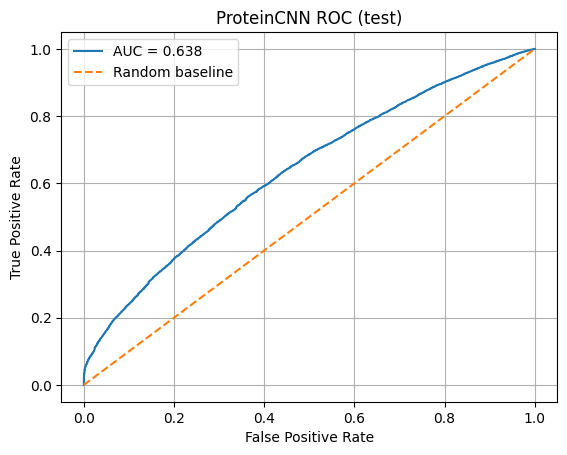

In [21]:
def plot_roc_cnn(y_true, y_score, title="CNN ROC"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return fpr, tpr, roc_auc

fpr, tpr, roc_auc = plot_roc_cnn(test_results_df["y_true"], test_results_df["y_score"], title="ProteinCNN ROC (test)")

In [22]:
def get_topk_df(df, y_true, y_scores, y_pred, top_idx):
    topk_df = df.iloc[top_idx].copy().assign(
        y_true=y_true[top_idx],
        pred_score=y_scores[top_idx],
        pred_label=y_pred[top_idx]
    )
    tp_topk_df = topk_df[
        (topk_df["y_true"] == 1) & (topk_df["pred_label"] == 1)
    ].copy()
    return tp_topk_df



In [23]:
tp_top100_df = get_topk_df(test_df, test_results_df["y_true"], test_results_df["y_score"], test_results_df["pred_label"], test_at_100["top_idx"])

In [24]:
export_df = tp_top100_df[[
    "Cluster_number",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]

In [25]:
export_df.to_csv(r"outputs\Round3\Predictions\new_finetuned_cnn_cdr3_predictions_updated_90.csv", index=False)
print("Saved only confident predictions ")
print("Number of confident predictions:", len(export_df))

Saved only confident predictions 
Number of confident predictions: 100
